### Prova map matching with noiseplanet 

In [1]:
import pandas as pd
data = pd.read_parquet('data/trips_pointv3_cleaned.parquet')

In [2]:
data.head(2)

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07


In [3]:
data.point_latitude = data.point_latitude.astype(float)
data.point_longitude = data.point_longitude.astype(float)

In [4]:
track = []
data = data.sort_values(by=['unique_id'])
for pt in range(len(data)):
    if data.unique_id[pt] == '24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07':
        track.append([data.point_latitude[pt], data.point_longitude[pt]])
    else:
        break

In [6]:
import numpy as np
track = np.array(track)
track

array([[46.052974, 11.120415],
       [46.052951, 11.120469],
       [46.052905, 11.120811],
       [46.052874, 11.121122],
       [46.052732, 11.121525],
       [46.053044, 11.121877],
       [46.053155, 11.122239],
       [46.053186, 11.122459],
       [46.053119, 11.122809],
       [46.052845, 11.122992],
       [46.052522, 11.123281],
       [46.052544, 11.123864],
       [46.052524, 11.124577],
       [46.052524, 11.125244],
       [46.052342, 11.12589 ],
       [46.052269, 11.126517],
       [46.052276, 11.127284],
       [46.052318, 11.128012],
       [46.052589, 11.128718],
       [46.052701, 11.129312],
       [46.052876, 11.129551]])

In [7]:
import numpy as np
import osmnx as ox
from noiseplanet.matcher import matching

graph = matching.model.graph_from_track(track)


In [8]:
track_coor, route_corr, edgeid, stats = matching.match(graph, track, method='nearest')

c:\Users\luisa\Anaconda3\lib\site-packages\osmnx\distance.py:455: UserWarning: The `get_nearest_edges` function has been deprecated and will be removed in a future release. Use the more efficient `distance.nearest_edges` instead.
  warnings.warn(msg)
c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_f

In [23]:
from noiseplanet.ui.foroute import plot_html

# Plot the graph
plot_html(track, track_corr=track_coor, route_corr=route_corr,
          proj=True, show_graph=True)

c:\Users\luisa\Anaconda3\lib\site-packages\osmnx\folium.py:64: UserWarning: `edge_color` has been deprecated and will be removed: use kwargs instead
  warn("`edge_color` has been deprecated and will be removed: use kwargs instead")
c:\Users\luisa\Anaconda3\lib\site-packages\osmnx\folium.py:67: UserWarning: `edge_width` has been deprecated and will be removed: use kwargs instead
  warn("`edge_width` has been deprecated and will be removed: use kwargs instead")


In [ ]:
# save the graph
# prova_mm = plot_html(track, track_corr=track_coor, route_corr=route_corr,
#           proj=True, show_graph=True)
# prova_mm.save("prova_mm.html")

In [12]:
# bounding box
import shapefile as shp
sf = shp.Reader("data/static/ambito_esercizio_monopattini.shp")
sf.bbox

[661307.343950298, 5099838.8559602, 665702.362587872, 5111587.63330715]

In [13]:
minx, miny, maxx, maxy = sf.bbox

In [14]:
minx, miny, maxx, maxy

(661307.343950298, 5099838.8559602, 665702.362587872, 5111587.63330715)

In [15]:
from pyproj import Proj, transform

inProj = Proj(init='epsg:25832', preserve_units=True) # source coordinate system
outProj = Proj(init='epsg:4326') # destination coordinate system

minx, miny = transform(inProj, outProj, minx, miny)
maxx, maxy = transform(inProj, outProj, maxx, maxy)

c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\luisa\AppData\Local\Temp\ipykernel_16780\91068550.py:6: DeprecationWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  minx, miny

In [16]:
# Create graph using osmread
# to select the roads -> here selected highway and ways tags
# check other possible tags here: https://wiki.openstreetmap.org/wiki/Key:highway

from leuvenmapmatching.map.inmem import InMemMap
# from osmnx.graph import graph_from_xml
# from osmnx.settings import osm_xml_node_tags, osm_xml_node_attrs, osm_xml_way_tags, osm_xml_way_attrs

map_con = InMemMap("myosm", use_latlon=True, use_rtree=True, index_edges=True)

map_con.purge()


In [17]:
from leuvenmapmatching.matcher.distance import DistanceMatcher
from leuvenmapmatching.util.gpx import gpx_to_path

# track -> list of latitude-longitude coordinates
matcher = DistanceMatcher(map_con,
                         max_dist=100, max_dist_init=25,  # meter
                         min_prob_norm=0.001,
                         non_emitting_length_factor=0.75,
                         obs_noise=50, obs_noise_ne=75,  # meter
                         dist_noise=50,  # meter
                         non_emitting_states=True,
                         max_lattice_width=5)
states, lastidx = matcher.match(track)

In [18]:
import osmnx
graph = ox.graph_from_place('Trento, Italy', network_type='drive')
graph_proj = ox.project_graph(graph)

# Create GeoDataFrames
nodes, edges = ox.graph_to_gdfs(graph_proj, nodes=True, edges=True)

nodes_proj = nodes.to_crs("EPSG:4326")
edges_proj = edges.to_crs("EPSG:4326")

for nid, row in nodes_proj.iterrows():
    map_con.add_node(nid, (row['lat'], row['lon']))

# adding edges using networkx graph
for nid1, nid2, _ in graph.edges:
    map_con.add_edge(nid1, nid2)

c:\Users\luisa\Anaconda3\lib\site-packages\osmnx\geocoder.py:110: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  gdf = gdf.append(_geocode_query_to_gdf(q, wr, by_osmid))


In [19]:
nodes_proj

,y,x,street_count,lon,lat,highway,ref,geometry
osmid,,,,,,,,
9192208,5.085802e+06,658246.336644,3,11.040291,45.907566,NaN,NaN,POINT (11.04029 45.90757)
7659399674,5.085761e+06,658227.876629,3,11.040040,45.907206,NaN,NaN,POINT (11.04004 45.90721)
2499751941,5.085873e+06,658270.594248,3,11.040628,45.908205,NaN,NaN,POINT (11.04063 45.90821)
9192259,5.079365e+06,655459.609017,3,11.002303,45.850306,NaN,NaN,POINT (11.00230 45.85031)
9201425,5.079370e+06,655460.503504,3,11.002316,45.850347,NaN,NaN,POINT (11.00232 45.85035)
...,...,...,...,...,...,...,...,...
8841393079,5.111066e+06,636821.903298,1,10.771453,46.139440,NaN,NaN,POINT (10.77145 46.13944)
8841398480,5.111180e+06,636866.358401,1,10.772061,46.140457,NaN,NaN,POINT (10.77206 46.14046)
8841412214,5.110972e+06,636877.894486,1,10.772151,46.138585,NaN,NaN,POINT (10.77215 46.13859)


In [164]:
track = []
data = data.sort_values(by=['unique_id'])
for pt in range(len(data)):
    if data.unique_id[pt] == '24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07':
        track.append([data.point_latitude[pt], data.point_longitude[pt]])
    else:
        break

In [165]:
track

[[46.052974, 11.120415],
 [46.052951, 11.120469],
 [46.052905, 11.120811],
 [46.052874, 11.121122],
 [46.052732, 11.121525],
 [46.053044, 11.121877],
 [46.053155, 11.122239],
 [46.053186, 11.122459],
 [46.053119, 11.122809],
 [46.052845, 11.122992],
 [46.052522, 11.123281],
 [46.052544, 11.123864],
 [46.052524, 11.124577],
 [46.052524, 11.125244],
 [46.052342, 11.12589],
 [46.052269, 11.126517],
 [46.052276, 11.127284],
 [46.052318, 11.128012],
 [46.052589, 11.128718],
 [46.052701, 11.129312],
 [46.052876, 11.129551]]

In [166]:
from leuvenmapmatching.matcher.distance import DistanceMatcher
from leuvenmapmatching.map.inmem import InMemMap

map_con = InMemMap("mymap", use_latlon=True, use_rtree=True, index_edges=True)


matcher = DistanceMatcher(map_con, max_dist=2, obs_noise=1, min_prob_norm=0.5)
states, _ = matcher.match(track)
states, _ = matcher.match(track, expand=True)
nodes = matcher.path_pred_onlynodes

print("States\n------")
print(states)
print("Nodes\n------")
print(nodes)
print("")
matcher.print_lattice_stats()

States
------
[]
Nodes
------
[]

Stats lattice
-------------
nbr levels               : 21
nbr lattice              : 0
avg lattice[level]       : 0.0
min lattice[level]       : 0
max lattice[level]       : 0


Lowered zoom level to keep map size reasonable. (z = 17)


(None, <AxesSubplot:xlabel='Longitude', ylabel='Latitude'>)

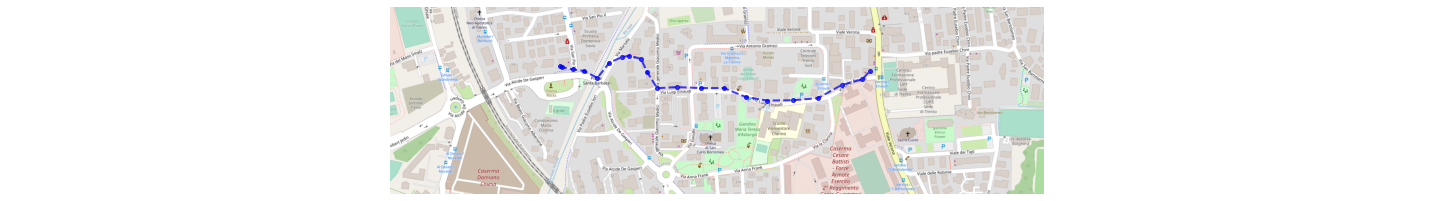

In [167]:
from leuvenmapmatching import visualization as mmviz

mmviz.plot_map(map_con, matcher=matcher,
                use_osm=True, zoom_path=True,
                show_labels=False, show_matching=True, show_graph=False) #filename="my_osm_plot.png")

(<Figure size 1440x144.536 with 1 Axes>,
 <AxesSubplot:xlabel='Longitude', ylabel='Latitude'>)

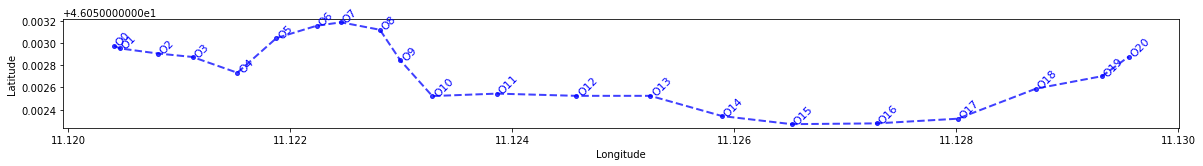

In [146]:
mmviz.plot_map(map_con, matcher=matcher,
               show_labels=True, show_matching=True, show_graph=True)

Lowered zoom level to keep map size reasonable. (z = 17)


(None, <AxesSubplot:xlabel='Longitude', ylabel='Latitude'>)

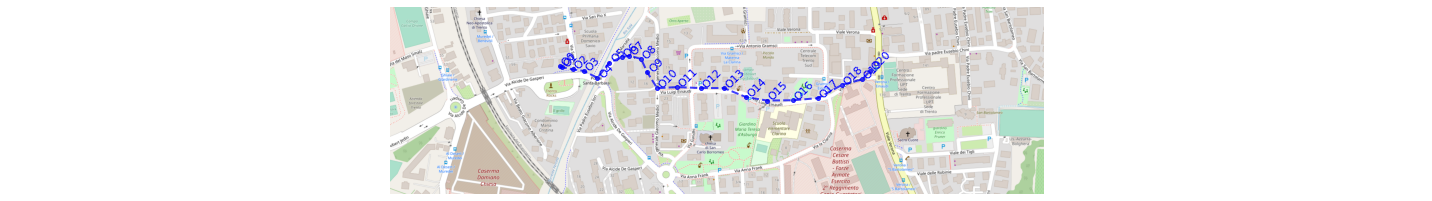

In [147]:
mmviz.plot_map(map_con, matcher=matcher,
                use_osm=True, zoom_path=True,
                show_labels=True, show_matching=True, show_graph=True) 